<a href="https://colab.research.google.com/github/Dkaushani/global-trade-network-analytics.ipynb/blob/main/Global_Commodity_Trade_%26_Risk_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
print(os.listdir('/content/'))

['.config', 'sample_data']


In [2]:
from google.colab import files
uploaded = files.upload()

Saving TradeData_8_19_2026_21_5_1.csv to TradeData_8_19_2026_21_5_1.csv


✅ Total country-to-country trade flows found: 5802

Top 5 Largest Fertilizer Importers/Exporters in 2022:
     Reporter             Partner  TradeValue_Millions
314    Brazil               China          1558.836795
2809    India                Oman          1270.810543
326    Brazil                Oman          1084.855005
334    Brazil  Russian Federation          1073.795288
333    Brazil               Qatar           967.496790


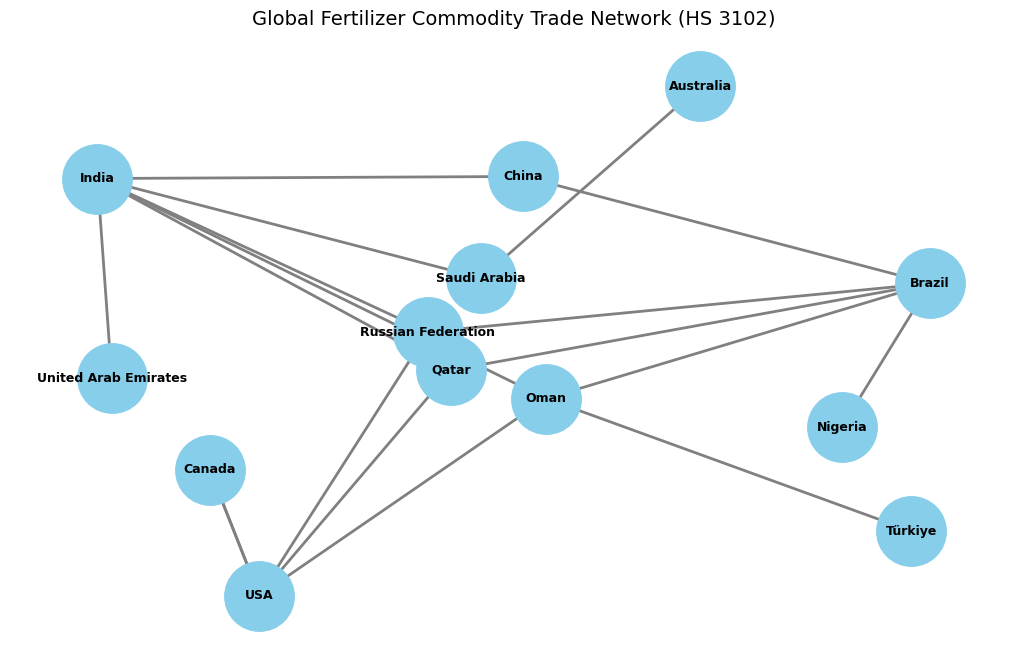

In [3]:
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Locate uploaded CSV file
csv_files = [f for f in os.listdir('/content/') if f.endswith('.csv')]
file_path = f"/content/{csv_files[0]}"

# 2. Read dataset using index_col=False to prevent header alignment shifts
df = pd.read_csv(file_path, encoding='latin1', low_memory=False, index_col=False)

# 3. Extract relevant columns
df_clean = df[['reporterDesc', 'partnerDesc', 'primaryValue']].dropna()
df_clean.columns = ['Reporter', 'Partner', 'TradeValue_USD']

# 4. Clean trade values and convert to Millions ($M)
df_clean['TradeValue_USD'] = pd.to_numeric(df_clean['TradeValue_USD'], errors='coerce')
df_clean['TradeValue_Millions'] = df_clean['TradeValue_USD'] / 1_000_000

# 5. Filter out aggregate "World" rows and self-trade
df_clean = df_clean[~df_clean['Partner'].astype(str).str.contains('World|total', case=False, na=False)]
df_clean = df_clean[~df_clean['Reporter'].astype(str).str.contains('World|total', case=False, na=False)]
df_clean = df_clean[df_clean['Reporter'] != df_clean['Partner']]
df_clean = df_clean[df_clean['TradeValue_Millions'] > 0]

print(f"✅ Total country-to-country trade flows found: {len(df_clean)}")
print("\nTop 5 Largest Fertilizer Importers/Exporters in 2022:")
print(df_clean.sort_values(by='TradeValue_Millions', ascending=False)[['Reporter', 'Partner', 'TradeValue_Millions']].head(5))

# 6. Plot Network Graph of the Top 20 Global Trade Flows
top_flows = df_clean.sort_values(by='TradeValue_Millions', ascending=False).head(20)

G = nx.from_pandas_edgelist(
    top_flows,
    source='Partner',      # Exporter
    target='Reporter',     # Importer
    edge_attr='TradeValue_Millions',
    create_using=nx.DiGraph()
)

plt.figure(figsize=(13, 8))
pos = nx.spring_layout(G, k=0.8, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue')
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', arrows=True, arrowsize=18)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title("Global Fertilizer Commodity Trade Network (HS 3102)", fontsize=14)
plt.axis('off')
plt.show()

In [4]:
import os
import sqlite3
import pandas as pd
import networkx as nx

# 1. Locate the uploaded CSV file automatically
csv_files = [f for f in os.listdir('/content/') if f.endswith('.csv')]
if not csv_files:
    # Fallback to local directory check if running outside /content/
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

file_path = csv_files[0]
print(f"✅ Processing File: {file_path}")

# 2. Load & Clean Data (Fixing index offset with index_col=False)
df = pd.read_csv(file_path, encoding='latin1', low_memory=False, index_col=False)

df_clean = df[['reporterDesc', 'partnerDesc', 'primaryValue', 'refYear']].dropna(subset=['primaryValue'])
df_clean.columns = ['Reporter', 'Partner', 'TradeValue_USD', 'Year']
df_clean['TradeValue_USD'] = pd.to_numeric(df_clean['TradeValue_USD'], errors='coerce')
df_clean['TradeValue_Millions'] = df_clean['TradeValue_USD'] / 1_000_000

# Remove aggregate 'World' entries and self-trade
df_clean = df_clean[~df_clean['Partner'].astype(str).str.contains('World|total', case=False, na=False)]
df_clean = df_clean[~df_clean['Reporter'].astype(str).str.contains('World|total', case=False, na=False)]
df_clean = df_clean[df_clean['Reporter'] != df_clean['Partner']]
df_clean = df_clean[df_clean['TradeValue_Millions'] > 0]

print(f"✅ Valid Country-to-Country Rows: {len(df_clean)}")

# ------------------------------------------------------------------
# PART A: DATABASE INTEGRATION & ADVANCED SQL
# ------------------------------------------------------------------
conn = sqlite3.connect('trade_analytics.db')
df_clean.to_sql('tbl_trade_flows', conn, index=False, if_exists='replace')

# Create index for query performance
conn.execute("CREATE INDEX IF NOT EXISTS idx_rep_part ON tbl_trade_flows(Reporter, Partner);")

# SQL Query: Extract Top 3 Suppliers Per Importer using Window Functions (DENSE_RANK)
sql_query = """
WITH RankedSuppliers AS (
    SELECT
        Reporter AS Importer,
        Partner AS Exporter,
        SUM(TradeValue_Millions) AS Total_Trade_Millions,
        DENSE_RANK() OVER (
            PARTITION BY Reporter
            ORDER BY SUM(TradeValue_Millions) DESC
        ) AS Supplier_Rank
    FROM tbl_trade_flows
    GROUP BY Reporter, Partner
    HAVING SUM(TradeValue_Millions) >= 10.0
)
SELECT
    Importer,
    Exporter,
    ROUND(Total_Trade_Millions, 2) AS Total_Trade_Millions,
    Supplier_Rank
FROM RankedSuppliers
WHERE Supplier_Rank <= 3
ORDER BY Importer ASC, Supplier_Rank ASC;
"""

df_sql_results = pd.read_sql_query(sql_query, conn)
conn.close()

print("\n--- SQL Window Function Output: Top 3 Suppliers Per Country (Sample) ---")
print(df_sql_results.head(10))

# ------------------------------------------------------------------
# PART B: NETWORK CENTRALITY METRICS
# ------------------------------------------------------------------
top_flows = df_clean.sort_values(by='TradeValue_Millions', ascending=False).head(150)

G = nx.from_pandas_edgelist(
    top_flows,
    source='Partner',
    target='Reporter',
    edge_attr='TradeValue_Millions',
    create_using=nx.DiGraph()
)

# Compute centralities
in_degree = nx.in_degree_centrality(G)      # Import Dependency Score
out_degree = nx.out_degree_centrality(G)    # Export Dominance Score
betweenness = nx.betweenness_centrality(G, weight='TradeValue_Millions') # Chokepoint/Transit Score
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)                # Network Influence Score

centrality_df = pd.DataFrame({
    'Country': list(in_degree.keys()),
    'In_Degree_Import_Score': list(in_degree.values()),
    'Out_Degree_Export_Score': list(out_degree.values()),
    'Betweenness_Chokepoint_Score': list(betweenness.values()),
    'Eigenvector_Influence_Score': list(eigenvector.values())
}).sort_values(by='Betweenness_Chokepoint_Score', ascending=False)

print("\n--- Top Chokepoint Economies (Ranked by Betweenness Centrality) ---")
print(centrality_df.head(10))

✅ Processing File: TradeData_8_19_2026_21_5_1.csv
✅ Valid Country-to-Country Rows: 5802

--- SQL Window Function Output: Top 3 Suppliers Per Country (Sample) ---
    Importer                          Exporter  Total_Trade_Millions  \
0     Angola                             China                 33.00   
1     Angola                      South Africa                 10.87   
2  Argentina                           Nigeria                253.93   
3  Argentina  Bolivia (Plurinational State of)                242.85   
4  Argentina                      Turkmenistan                235.59   
5    Armenia                Russian Federation                 28.46   
6    Armenia                           Georgia                 24.68   
7  Australia                      Saudi Arabia                548.57   
8  Australia                             Qatar                396.50   
9  Australia                          Malaysia                338.98   

   Supplier_Rank  
0              1  
1      

In [5]:
# 1. Install required packages first
!pip install -q streamlit plotly networkx

import os
import sqlite3
import pandas as pd
import networkx as nx

# 2. Locate uploaded CSV file
csv_files = [f for f in os.listdir('/content/') if f.endswith('.csv')]
if not csv_files:
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

file_path = csv_files[0]
print(f" Processing File: {file_path}")

# 3. Read and clean dataset
df = pd.read_csv(file_path, encoding='latin1', low_memory=False, index_col=False)

df_clean = df[['reporterDesc', 'partnerDesc', 'primaryValue', 'refYear']].dropna(subset=['primaryValue'])
df_clean.columns = ['Reporter', 'Partner', 'TradeValue_USD', 'Year']
df_clean['TradeValue_USD'] = pd.to_numeric(df_clean['TradeValue_USD'], errors='coerce')
df_clean['TradeValue_Millions'] = df_clean['TradeValue_USD'] / 1_000_000

df_clean = df_clean[~df_clean['Partner'].astype(str).str.contains('World|total', case=False, na=False)]
df_clean = df_clean[~df_clean['Reporter'].astype(str).str.contains('World|total', case=False, na=False)]
df_clean = df_clean[df_clean['Reporter'] != df_clean['Partner']]
df_clean = df_clean[df_clean['TradeValue_Millions'] > 0]

# 4. Database & SQL Processing
conn = sqlite3.connect('trade_analytics.db')
df_clean.to_sql('tbl_trade_flows', conn, index=False, if_exists='replace')
conn.execute("CREATE INDEX IF NOT EXISTS idx_rep_part ON tbl_trade_flows(Reporter, Partner);")

sql_query = """
WITH RankedSuppliers AS (
    SELECT
        Reporter AS Importer,
        Partner AS Exporter,
        SUM(TradeValue_Millions) AS Total_Trade_Millions,
        DENSE_RANK() OVER (
            PARTITION BY Reporter
            ORDER BY SUM(TradeValue_Millions) DESC
        ) AS Supplier_Rank
    FROM tbl_trade_flows
    GROUP BY Reporter, Partner
    HAVING SUM(TradeValue_Millions) >= 10.0
)
SELECT
    Importer,
    Exporter,
    ROUND(Total_Trade_Millions, 2) AS Total_Trade_Millions,
    Supplier_Rank
FROM RankedSuppliers
WHERE Supplier_Rank <= 3
ORDER BY Importer ASC, Supplier_Rank ASC;
"""

df_sql_results = pd.read_sql_query(sql_query, conn)
conn.close()

# 5. Network Centrality Calculations
top_flows = df_clean.sort_values(by='TradeValue_Millions', ascending=False).head(150)
G = nx.from_pandas_edgelist(top_flows, source='Partner', target='Reporter', edge_attr='TradeValue_Millions', create_using=nx.DiGraph())

in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)
betweenness = nx.betweenness_centrality(G, weight='TradeValue_Millions')
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

centrality_df = pd.DataFrame({
    'Country': list(in_degree.keys()),
    'In_Degree_Import_Score': list(in_degree.values()),
    'Out_Degree_Export_Score': list(out_degree.values()),
    'Betweenness_Chokepoint_Score': list(betweenness.values()),
    'Eigenvector_Influence_Score': list(eigenvector.values())
}).sort_values(by='Betweenness_Chokepoint_Score', ascending=False)

# Export output CSVs
df_sql_results.to_csv('top_3_suppliers.csv', index=False)
centrality_df.to_csv('centrality_scores.csv', index=False)
print(" Analytics pipeline complete and CSV files saved!")

# 6. Write app.py script file
app_code = """import streamlit as st
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import os

st.set_page_config(page_title="Global Trade Analytics Dashboard", layout="wide")
st.title(" Global Commodity Trade & Network Risk Dashboard")
st.markdown("Interactive Business Intelligence pipeline evaluating supply chain dependencies and centrality metrics.")

@st.cache_data
def load_data():
    csv_files = [f for f in os.listdir('/content/') if f.endswith('.csv')]
    if not csv_files:
        csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    if not csv_files:
        return pd.DataFrame()

    file_path = csv_files[0]
    df = pd.read_csv(file_path, encoding='latin1', low_memory=False, index_col=False)

    df_clean = df[['reporterDesc', 'partnerDesc', 'primaryValue', 'refYear']].dropna(subset=['primaryValue'])
    df_clean.columns = ['Importer', 'Exporter', 'TradeValue_USD', 'Year']
    df_clean['TradeValue_Millions'] = pd.to_numeric(df_clean['TradeValue_USD'], errors='coerce') / 1_000_000

    df_clean = df_clean[~df_clean['Exporter'].astype(str).str.contains('World|total', case=False, na=False)]
    df_clean = df_clean[~df_clean['Importer'].astype(str).str.contains('World|total', case=False, na=False)]
    df_clean = df_clean[df_clean['Importer'] != df_clean['Exporter']]
    df_clean = df_clean[df_clean['TradeValue_Millions'] > 0]

    return df_clean

df = load_data()

if not df.empty:
    st.sidebar.header(" Filter Controls")
    min_trade = st.sidebar.slider(
        "Minimum Trade Value ($ Millions)",
        min_value=5.0,
        max_value=float(df['TradeValue_Millions'].quantile(0.98)),
        value=50.0,
        step=5.0
    )

    all_countries = sorted(list(set(df['Importer']).union(set(df['Exporter']))))
    selected_countries = st.sidebar.multiselect("Filter by Country/Node", options=all_countries, default=[])

    df_filtered = df[df['TradeValue_Millions'] >= min_trade]
    if selected_countries:
        df_filtered = df_filtered[
            (df_filtered['Importer'].isin(selected_countries)) |
            (df_filtered['Exporter'].isin(selected_countries))
        ]

    col1, col2, col3 = st.columns(3)
    col1.metric("Total Filtered Trade", f"${df_filtered['TradeValue_Millions'].sum():,.2f} M")
    col2.metric("Active Trade Corridors", len(df_filtered))
    col3.metric("Participating Economies", len(set(df_filtered['Importer']).union(set(df_filtered['Exporter']))))

    st.subheader(" Interactive Trade Corridor Network")
    G = nx.from_pandas_edgelist(
        df_filtered, source='Exporter', target='Importer',
        edge_attr='TradeValue_Millions', create_using=nx.DiGraph()
    )

    pos = nx.spring_layout(G, k=0.6, seed=42)

    edge_x, edge_y = [], []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])

    edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=1, color='#888'), hoverinfo='none', mode='lines')

    node_x, node_y, node_text = [], [], []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(node)

    node_trace = go.Scatter(
        x=node_x, y=node_y, mode='markers+text', hoverinfo='text', text=node_text,
        textposition="top center",
        marker=dict(
            showscale=True, colorscale='YlGnBu', size=18,
            colorbar=dict(title='Degree Centrality'),
            color=[len(list(G.neighbors(n))) for n in G.nodes()]
        )
    )

    fig = go.Figure(data=[edge_trace, node_trace], layout=go.Layout(showlegend=False, hovermode='closest', margin=dict(b=0,l=0,r=0,t=0)))
    st.plotly_chart(fig, use_container_width=True)

    st.subheader(" Underlying Trade Data")
    st.dataframe(df_filtered.sort_values(by='TradeValue_Millions', ascending=False), use_container_width=True)
"""

with open("app.py", "w") as f:
    f.write(app_code)

print(" app.py file successfully created!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 105.6 MB/s eta 0:00:00
 Processing File: TradeData_8_19_2026_21_5_1.csv
 Analytics pipeline complete and CSV files saved!
 app.py file successfully created!


In [ ]:
import os
import subprocess
import time

# 1. Install Cloudflare Tunnel
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null 2>&1

# 2. Launch Streamlit app in background
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "0.0.0.0"])

time.sleep(3) # Wait for Streamlit to start

# 3. Create Cloudflare Tunnel to port 8501
print(" Opening Cloudflare Tunnel...")
!cloudflared tunnel --url http://localhost:8501

 Opening Cloudflare Tunnel...
2026-08-20T00:43:28Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-20T00:43:28Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-20T00:43:33Z INF +--------------------------------------------------------------------------------------------+
2026-08-20T00:43:33Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-20T00:43:33Z INF |  https://properties-yet-